<a href="https://colab.research.google.com/github/maats01/challenge-telecom-x/blob/main/TelecomX_BR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracão

In [164]:
import pandas as pd
import numpy as np

In [165]:
url = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/refs/heads/main/TelecomX_Data.json'

df = pd.read_json(url)
df

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


In [166]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [167]:
columns_to_normalize = ['customer', 'phone', 'internet', 'account']
df_final = df.drop(columns=columns_to_normalize)

for col in columns_to_normalize:
  temp_df = pd.json_normalize(df[col])
  df_final = pd.concat([df_final, temp_df], axis=1)

df = df_final
df

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


#🔧 Transformação

#### Dicionário de dados

* `customerID`: número de identificação único de cada cliente
* `Churn`: se o cliente deixou ou não a empresa
* `gender`: gênero (masculino e feminino)
* `SeniorCitizen`: informação sobre um cliente ter ou não idade igual ou maior que 65 anos
* `Partner`:  se o cliente possui ou não um parceiro ou parceira
* `Dependents`: se o cliente possui ou não dependentes
* `tenure`:  meses de contrato do cliente
* `PhoneService`: assinatura de serviço telefônico
* `MultipleLines`: assisnatura de mais de uma linha de telefone
* `InternetService`: assinatura de um provedor internet
* `OnlineSecurity`: assinatura adicional de segurança online
* `OnlineBackup`: assinatura adicional de backup online
* `DeviceProtection`: assinatura adicional de proteção no dispositivo
* `TechSupport`: assinatura adicional de suporte técnico, menos tempo de espera
* `StreamingTV`: assinatura de TV a cabo
* `StreamingMovies`: assinatura de streaming de filmes
* `Contract`: tipo de contrato
* `PaperlessBilling`: se o cliente prefere receber online a fatura
* `PaymentMethod`: forma de pagamento
* `Charges.Monthly`: total de todos os serviços do cliente por mês
* `Charges.Total`: total gasto pelo cliente

1. Verificação de valores únicos

In [168]:
for col in df.columns:
  print(f'{col}: {df[col].unique()}')
  print('-'*40)

customerID: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
----------------------------------------
Churn: ['No' 'Yes' '']
----------------------------------------
gender: ['Female' 'Male']
----------------------------------------
SeniorCitizen: [0 1]
----------------------------------------
Partner: ['Yes' 'No']
----------------------------------------
Dependents: ['Yes' 'No']
----------------------------------------
tenure: [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]
----------------------------------------
PhoneService: ['Yes' 'No']
----------------------------------------
MultipleLines: ['No' 'Yes' 'No phone service']
----------------------------------------
InternetService: ['DSL' 'Fiber optic' 'No']
----------------------------------------
OnlineSecurity: ['No' 'Yes

Por algum motivo, a coluna `Churn` possui valores vazios. Tendo isso em mente, para deixar o DataFrame consistente, o ideal seria tentar atribuir `No` ou simplesmente remover esses registros. Para escolher a abordagem, podemos calcular a proporção de registros onde o `Churn` é vazio em comparação ao total de registros da base de dados. Se o valor for muito pequeno, podemos simplesmente ignorar os registros vazios.

2. Valores nulos

In [169]:
df.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


Nenhum valor nulo no DataFrame. Portanto, não precisamos nos preocupar com esse tipo de tratamento.

3. Valores vazios

In [170]:
df.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
customerID,0
Churn,224
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


Como podemos ver, a coluna `Churn` possui **224** valores vazios, o que corresponde a aproximadamente **3.08%** dos registros da base de dados. Como a proporção é bem pequena, podemos desconsiderar esses registros, pois eles não terão um grande impacto nas análises posteriores.

A coluna `Charges.Total` possui **11** valores vazios. Embora a proporção de valores vazios seja muito pequena em relação a base de dados, será feita uma análise posterior para decidir entre desconsiderar esses registros ou substituí-los por algum outro valor, antes de converter essa coluna para o tipo `float`.

4. Valores duplicados

In [171]:
df.duplicated().sum()

np.int64(0)

O DataFrame não possui valores duplicados. Portanto, não precisamos nos preocupar com esse tipo de tratamento.

In [172]:
df = df[df['Churn'].str.strip() != '']
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 
 17  

Como podemos ver, os `224` registros que tinham um valor vazio na coluna `Churn` foram corretamente removidos. Para fazer uma verificação final, vamos checar por valores vazios novamente.

In [173]:
print('Valores vazios:')
df.apply(lambda x: x.astype(str).str.strip() == '').sum()

Valores vazios:


,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


Agora o `Churn` está zerado. Nos resta somente analisar a coluna `Charges.Total` e convertê-la para `float64`.

In [174]:
df[df['Charges.Total'].str.strip() == '']

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
975,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,
1775,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,
1955,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,...,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,
2075,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,
2232,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,
2308,3213-VVOLG,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,
2930,4075-WKNIU,No,Female,0,Yes,Yes,0,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,
3134,4367-NUYAO,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,
3203,4472-LVYGI,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,
4169,5709-LVOEQ,No,Female,0,Yes,Yes,0,Yes,No,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,


Há um padrão nessa seleção. Se observarmos a coluna `tenure`, vamos notar que em todos os registros onde `Charges.Total` é vazio, ela possui **0**. Vale notar que na coluna `Churn`, todos os registros são `No`, implicando que nenhum desses clientes deixou a empresa, portanto são todos clientes ativos no momento.

Quanto o `tenure` é igual a **0**, significa que o cliente está no seu primeiro mês de contrato. Portanto, ele ainda não efetuou nenhum pagamento para a Telecom X.

Por isso, a coluna `Charges.total` está vazia para esses casos. Entretanto, para fins de análise de dados, vou converter o tipo dessa coluna para `float64`, para ficar consistente com a coluna `Charges.monthly` e facilitar as análises posteriores. Para isso, vou substituir os valores vazios por **0:**

In [175]:
df.loc[df['Charges.Total'].str.strip() == '', 'Charges.Total'] = '0'
df[df['tenure'] == 0]

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
975,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,0
1775,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,0
1955,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,...,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,0
2075,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,0
2232,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,0
2308,3213-VVOLG,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,0
2930,4075-WKNIU,No,Female,0,Yes,Yes,0,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,0
3134,4367-NUYAO,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,0
3203,4472-LVYGI,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,0
4169,5709-LVOEQ,No,Female,0,Yes,Yes,0,Yes,No,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,0


Com todos os valores vazios substituidos por **0**, basta converter a coluna inteira para `float64`:

In [176]:
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce').fillna(0)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 
 17  

/tmp/ipython-input-2095185207.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Para ter uma visão mais detalhada sobre o faturamento de cada cliente, vamos criar a coluna `gasto_diario`, que vai nos dizer quanto que o cliente paga diariamente para a Telecom X.

In [177]:
df['gasto_diario'] = df['Charges.Monthly'] / 30
df.head()

/tmp/ipython-input-3701854067.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,gasto_diario
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


In [178]:
colunas = {
    'customerID': 'id',
    'gender': 'genero',
    'SeniorCitizen': 'tem +60',
    'Partner': 'possui_parceiro',
    'Dependents': 'possui_dependentes',
    'tenure': 'tempo_contrato',
    'PhoneService': 'servico_telefone',
    'MultipleLines': 'multiplas_linhas',
    'InternetService': 'tipo_internet',
    'OnlineSecurity': 'seguranca_online',
    'OnlineBackup': 'backup_online',
    'DeviceProtection': 'protecao_dispositivo',
    'TechSupport': 'suporte_tecnico',
    'StreamingTV': 'streaming_tv',
    'StreamingMovies': 'streaming_filmes',
    'Contract': 'tipo_contrato',
    'PaperlessBilling': 'fatura_digital',
    'PaymentMethod': 'metodo_pagamento',
    'Charges.Monthly': 'valor_mensal',
    'Charges.Total': 'total_cobrado'
}
df = df.rename(columns= colunas)
df.head()

,id,Churn,genero,tem +60,possui_parceiro,possui_dependentes,tempo_contrato,servico_telefone,multiplas_linhas,tipo_internet,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_cobrado,gasto_diario
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


In [179]:
df['Churn'] = df['Churn'].replace({'No': 'Não', 'Yes': 'Sim'})
df['genero'] = df['genero'].replace({'Female': 'Feminino', 'Male': 'Masculino'})
df['possui_parceiro'] = df['possui_parceiro'].replace({'Yes': 'Sim', 'No': 'Não'})
df['possui_dependentes'] = df['possui_dependentes'].replace({'Yes': 'Sim', 'No': 'Não'})
df['servico_telefone'] = df['servico_telefone'].replace({'Yes': 'Sim', 'No': 'Não'})
df['multiplas_linhas'] = df['multiplas_linhas'].replace({'No': 'Não', 'Yes': 'Sim', 'No phone service': 'Sem serviço de telefone'})
df['tipo_internet'] = df['tipo_internet'].replace({'No': 'Não'})
df['fatura_digital'] = df['fatura_digital'].replace({'Yes': 'Sim', 'No': 'Não'})
df['tipo_contrato'] = df['tipo_contrato'].replace({'One year': 'Anual', 'Month-to-month': 'Mensal', 'Two year': 'Bienal'})
df['metodo_pagamento'] = df['metodo_pagamento'].replace({
    'Mailed check': 'Cheque enviado',
    'Electronic check': 'Cheque eletrônico',
    'Credit card (automatic)': 'Cartão de crédito (automático)',
    'Bank transfer (automatic)': 'Transferência bancária (automática)'
})

columns_to_translate = ['seguranca_online', 'backup_online', 'protecao_dispositivo', 'suporte_tecnico', 'streaming_tv', 'streaming_filmes']
mapping = {'No': 'Não', 'Yes': 'Sim', 'No internet service': 'Sem serviço de internet'}
for col in columns_to_translate:
    df[col] = df[col].replace(mapping)

#📊 Carga e análise

In [180]:
import matplotlib.pyplot as plt

In [181]:
df.describe()

,tem +60,tempo_contrato,valor_mensal,total_cobrado,gasto_diario
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304,2.158723
std,0.368612,24.559481,30.090047,2266.794470,1.003002
min,0.000000,0.000000,18.250000,0.000000,0.608333
25%,0.000000,9.000000,35.500000,398.550000,1.183333
50%,0.000000,29.000000,70.350000,1394.550000,2.345000
75%,0.000000,55.000000,89.850000,3786.600000,2.995000
max,1.000000,72.000000,118.750000,8684.800000,3.958333


In [182]:
churn_count = df['Churn'].value_counts()
churn_count

,count
Churn,
Não,5174
Sim,1869


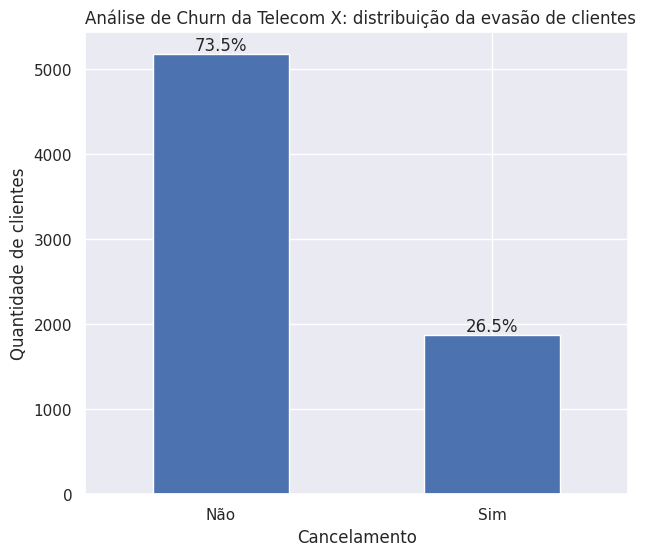

In [183]:
churn_percent = (churn_count / len(df)) * 100

ax = churn_count.plot(kind='bar', figsize=(7, 6))
plt.title('Análise de Churn da Telecom X: distribuição da evasão de clientes', loc='left')

for i, percent in enumerate(churn_percent):
  ax.text(i, churn_count.iloc[i] + 50, f'{percent:.1f}%', ha='center')

plt.ylabel('Quantidade de clientes')
plt.xlabel('Cancelamento')
plt.xticks(rotation=0)

plt.show()

In [184]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    7043 non-null   object 
 1   Churn                 7043 non-null   object 
 2   genero                7043 non-null   object 
 3   tem +60               7043 non-null   int64  
 4   possui_parceiro       7043 non-null   object 
 5   possui_dependentes    7043 non-null   object 
 6   tempo_contrato        7043 non-null   int64  
 7   servico_telefone      7043 non-null   object 
 8   multiplas_linhas      7043 non-null   object 
 9   tipo_internet         7043 non-null   object 
 10  seguranca_online      7043 non-null   object 
 11  backup_online         7043 non-null   object 
 12  protecao_dispositivo  7043 non-null   object 
 13  suporte_tecnico       7043 non-null   object 
 14  streaming_tv          7043 non-null   object 
 15  streaming_filmes      7043

In [185]:
import seaborn as sns

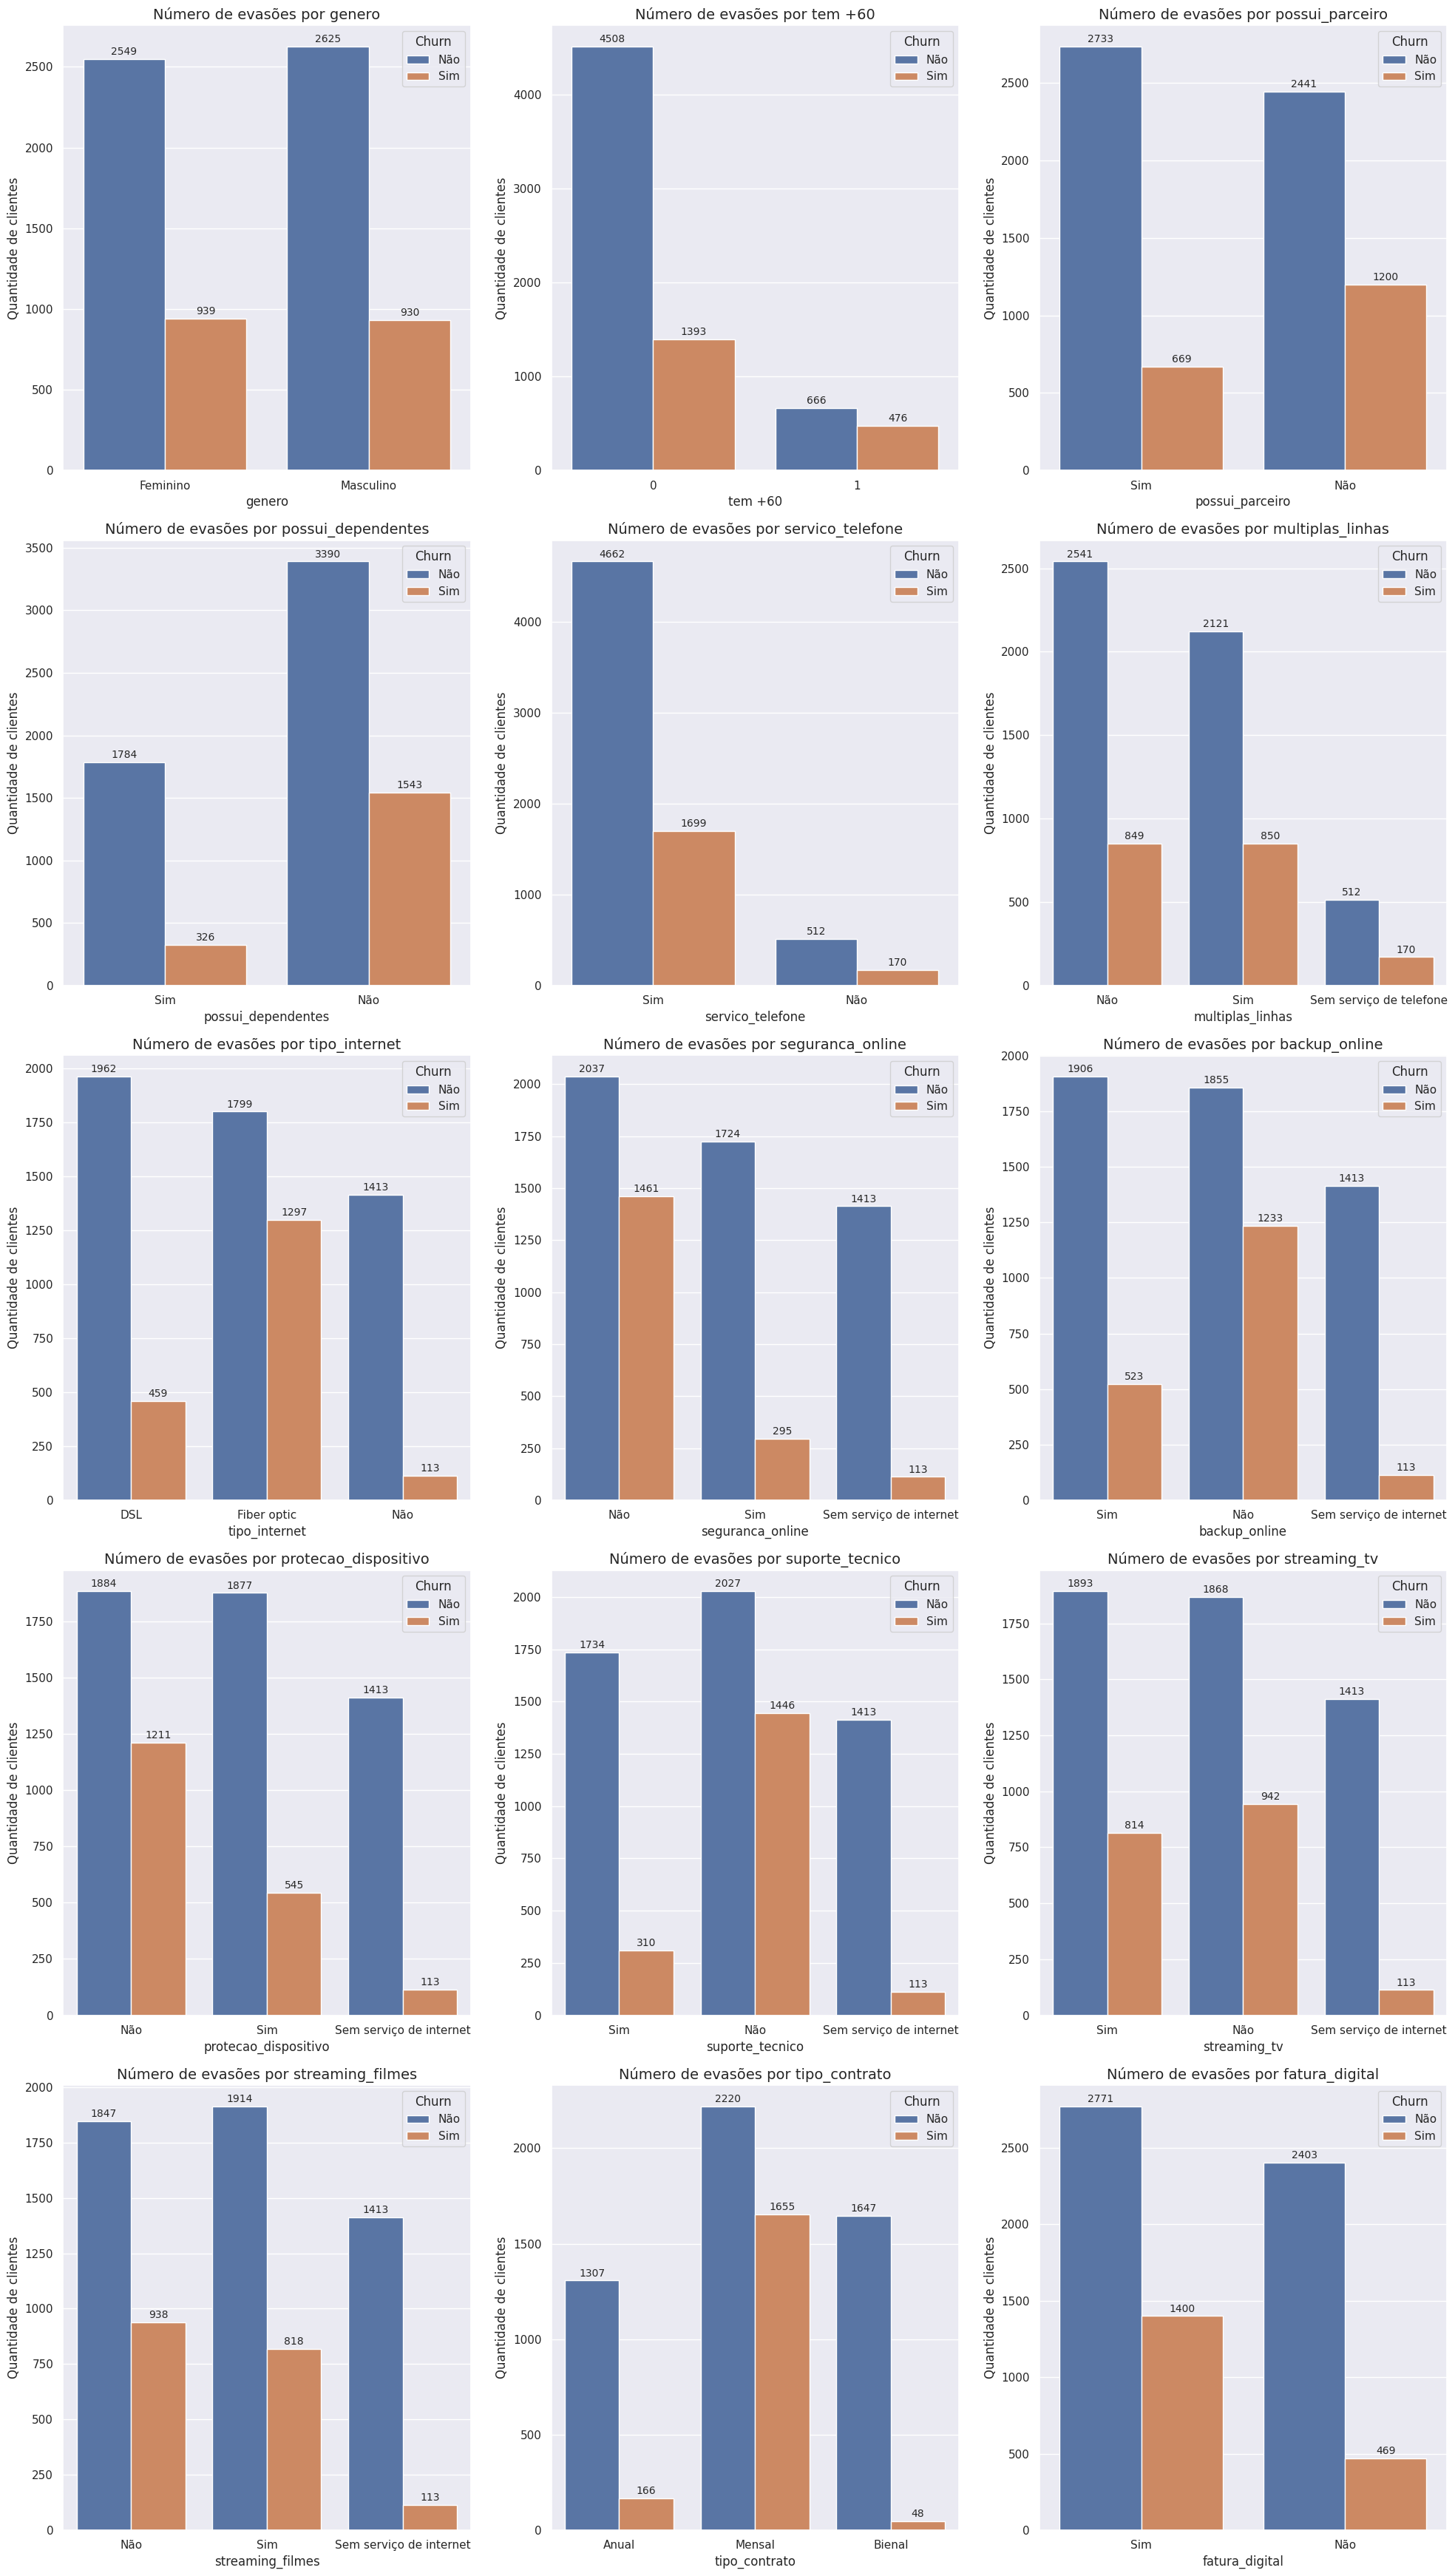

In [186]:
categorical_columns = df.columns.tolist()
columns_to_remove = ['id', 'Churn', 'gasto_diario', 'total_cobrado', 'valor_mensal', 'tempo_contrato', 'metodo_pagamento']
for col in columns_to_remove:
  categorical_columns.remove(col)

sns.set(rc={'figure.figsize': (20, 35)})

for i, col in enumerate(categorical_columns):
  plt.subplot(5, 3, i+1)
  ax = sns.countplot(data=df, x=col, hue='Churn')

  ax.set_title(f'Número de evasões por {col}', fontsize=14)
  ax.set_ylabel('Quantidade de clientes')
  ax.set_xlabel(col)

  for container in ax.containers:
    ax.bar_label(container, fontsize=10, padding=2)

plt.tight_layout()
plt.show()

In [187]:
import plotly.express as px

In [188]:
fig = px.histogram(data_frame=df, x='tempo_contrato', text_auto=True, color='Churn', barmode='group', title='Distribuição do tempo de contrato em relação a evasão de clientes')

fig.update_layout(width=1400, height=500,
                  xaxis_title='Tempo de contrato (meses)',
                  yaxis_title='Quantidade de cancelamentos')

fig.show()

In [189]:
churn_clients = df[df['Churn'] == 'Sim']
churn_rate = churn_clients.groupby('tempo_contrato')['Churn'].value_counts().reset_index()
churn_rate.drop('Churn', axis=1, inplace=True)
churn_rate.rename(columns={'count': 'churn_count'}, inplace=True)
churn_rate

,tempo_contrato,churn_count
0,1,380
1,2,123
2,3,94
3,4,83
4,5,64
...,...,...
67,68,9
68,69,8
69,70,11
70,71,6


In [190]:
total_customers_by_tenure = df.groupby('tempo_contrato').size().reset_index(name='total_count')
churn_rate = pd.merge(churn_rate, total_customers_by_tenure, on='tempo_contrato', how='left')
churn_rate['porcentagem'] = (churn_rate['churn_count'] / churn_rate['total_count']) * 100
churn_rate.rename(columns={'churn_count': 'cancelamentos'}, inplace=True)
churn_rate

,tempo_contrato,cancelamentos,total_count,porcentagem
0,1,380,613,61.990212
1,2,123,238,51.680672
2,3,94,200,47.000000
3,4,83,176,47.159091
4,5,64,133,48.120301
...,...,...,...,...
67,68,9,100,9.000000
68,69,8,95,8.421053
69,70,11,119,9.243697
70,71,6,170,3.529412


In [191]:
fig = px.line(data_frame=churn_rate, x='tempo_contrato', y='porcentagem', markers=True, title='Taxa de Churn por tempo de contrato')

fig.update_traces(line_width=2.5,
                  hovertemplate="<br>".join([
                      'tempo_contrato: %{x}',
                      'cancelamentos: %{y}',
                      'taxa: %{customdata[0]:.1f}%'
                  ]),
                  customdata=churn_rate[['porcentagem']])

fig.update_layout(width=1000, height=500,
                  xaxis_title='Tempo de contrato (meses)',
                  yaxis_title='Quantidade de cancelamentos')

fig.show()

In [192]:
fig = px.box(data_frame=df, x='Churn', y='total_cobrado', color='Churn', title='Distribuição do total gasto pela evasão de clientes')
fig.update_layout(width=1000, height=500,
                  yaxis_title='Total cobrado')

fig.show()

In [193]:
fig = px.box(data_frame=df, x='Churn', y='gasto_diario', color='Churn', title='Distribuição do gasto diário pela evasão de clientes')
fig.update_layout(width=1000, height=500,
                  yaxis_title='Gasto diário')

fig.show()

#📄Relatorio Final

**1. Introdução**

A empresa Telecom X está sofrendo com uma alta evasão de clientes (*Churn*), por conta disso foi realizada essa análise para tentar descobrir as possíveis razões disso, para resolver esse problema.

**2. Limpeza e tratamento de dados**

Os dados foram importados via *API* e processados utilizando a biblioteca `pandas` do **Python**.
- Os dados estavam originalmente em formato `json`, portanto foi utilizado o método `read_json` para importar a base de dados para o *notebook*.
- A estrutura da base de dados era composta por chaves e valores aninhados, portanto foi utilizado o método `json_normalize` para normalizar essas colunas que tinham valores aninhados e transformá-las em colunas únicas.
- Foi realizada a checagem de valores vazios, nulos, duplicados e de valores únicos nas colunas categóricas.
  - Com essa checagem, foi identificado que a coluna `Churn` possuia alguns registros vazios e que a coluna `Charges.Total` não estava com o tipo `float64`, que seria o tipo de dado adequado para ela, pois se trata de uma coluna numérica.
  - Os registros onde a coluna `Churn` era vazia foram eliminados do *dataset* pois eram pouquíssimos valores.
  - Na coluna `Charges.Total`, foi identificado que quando ela era vazia, era por causa da coluna `tenure` zerada (o que implica que aquele cliente ainda estava no primeiro mês de contrato). Portanto, os valores vazios foram substituidos por zero e a coluna foi convertida para `float64`.
- As colunas e os dados categóricos foram traduzidas para o português, para padronizar o *dataframe* e ajudar na visualização dos gráficos na etapa de análise exploratória de dados.

**3. Análise exploratória de dados**

Primeiramente, para ter uma noção da evasão dos clientes, foi realizada uma análise da distribuição de *Churn*, por meio de um gráfico de barras.

Como é possível ver no gráfico abaixo, **26.5%** dos clientes da Telecom X cancelaram o contrato, o que é uma quantia preocupante, indicando que realmente há algum problema em manter os clientes na Telecom X.

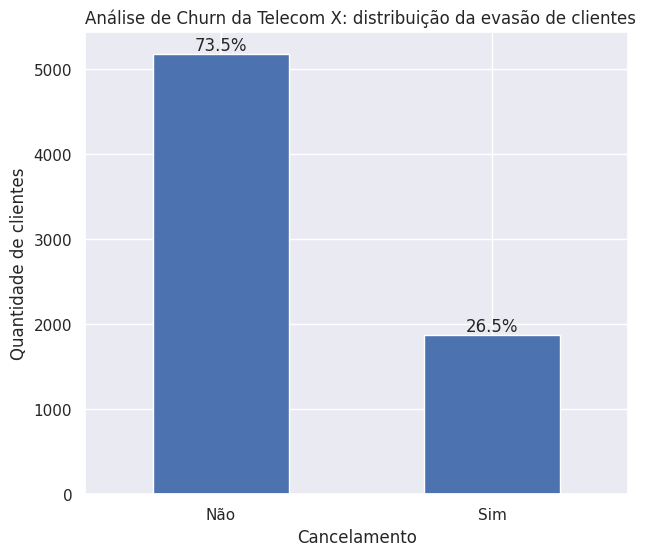

In [194]:
# @title
ax = churn_count.plot(kind='bar', figsize=(7, 6))
plt.title('Análise de Churn da Telecom X: distribuição da evasão de clientes', loc='left')

for i, percent in enumerate(churn_percent):
  ax.text(i, churn_count.iloc[i] + 50, f'{percent:.1f}%', ha='center')

plt.ylabel('Quantidade de clientes')
plt.xlabel('Cancelamento')
plt.xticks(rotation=0)

plt.show()

Foram analisadas as distribuições de evasões por variáveis categóricas do *dataset* (variáveis que indicam se o cliente possui tal serviço, por exemplo).

Foi notado que uma boa parcela dos cancelamentos resultaram de clientes que contrataram a Telecom X de modo mensal.

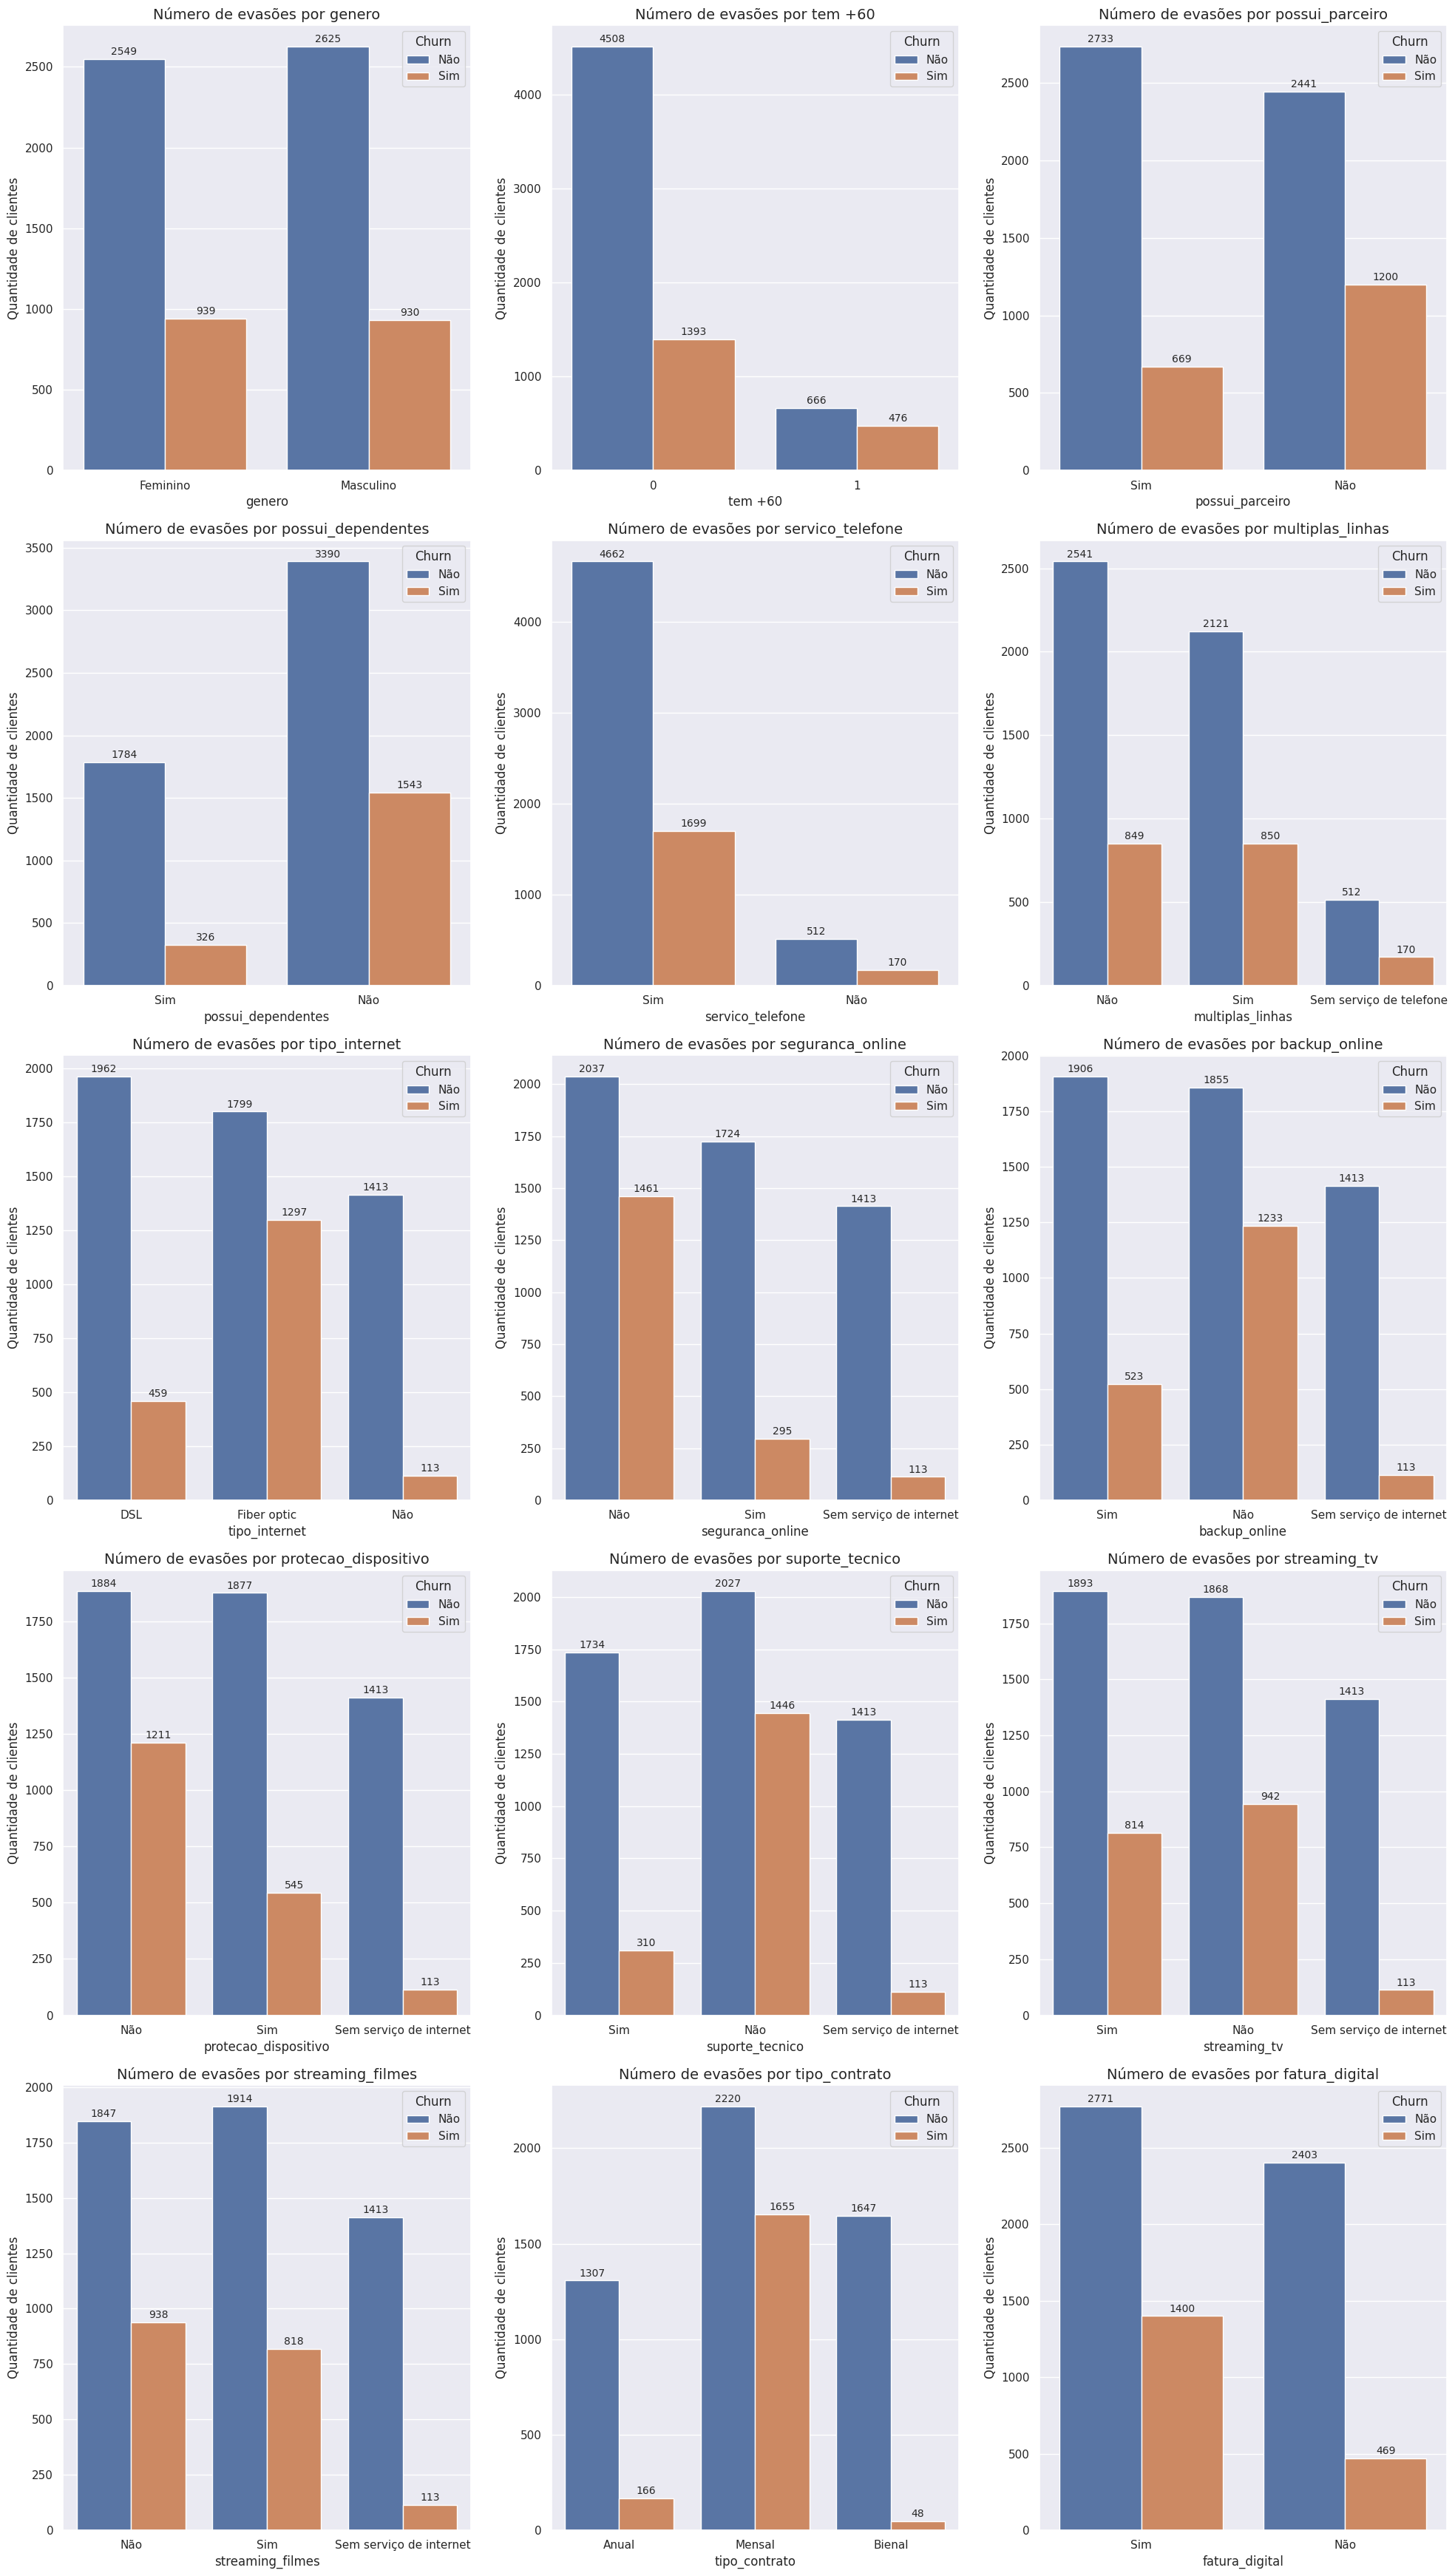

In [195]:
# @title
categorical_columns = df.columns.tolist()
columns_to_remove = ['id', 'Churn', 'gasto_diario', 'total_cobrado', 'valor_mensal', 'tempo_contrato', 'metodo_pagamento']
for col in columns_to_remove:
  categorical_columns.remove(col)

sns.set(rc={'figure.figsize': (20, 35)})

for i, col in enumerate(categorical_columns):
  plt.subplot(5, 3, i+1)
  ax = sns.countplot(data=df, x=col, hue='Churn')

  ax.set_title(f'Número de evasões por {col}', fontsize=14)
  ax.set_ylabel('Quantidade de clientes')
  ax.set_xlabel(col)

  for container in ax.containers:
    ax.bar_label(container, fontsize=10, padding=2)

plt.tight_layout()
plt.show()

Para confirmar, foi realizada uma análise referente a taxa de evasão por tempo de contrato.

Essa análise nos mostrou que a maior taxa de cancelamento foi de **61.99%**, no primeiro mês de contrato. No sexto mês de contrato, a taxa foi consideravelmente menor, porém ainda elevada, de **36.36%**.

A tendência da taxa é diminuir conforme o tempo, atingindo valores como **1.66%** em clientes com 72 meses de contrato. Entretanto, na maior parte do tempo, a taxa é superior a **10%**. Sendo que, nos primeiros 2 anos de tempo de contrato, a taxa de cancelamento é superior a **20%**, na maior parte dos casos.

In [196]:
# @title
fig = px.line(data_frame=churn_rate, x='tempo_contrato', y='porcentagem', markers=True, title='Taxa de Churn por tempo de contrato')

fig.update_traces(line_width=2.5,
                  hovertemplate="<br>".join([
                      'tempo_contrato: %{x}',
                      'taxa: %{y:.2f}%',
                      'cancelamentos: %{customdata[0]}',
                  ]),
                  customdata=churn_rate[['cancelamentos']])

fig.update_layout(width=1000, height=500,
                  xaxis_title='Tempo de contrato (meses)',
                  yaxis_title='Porcentagem de cancelamentos')

fig.show()

Também foi gerado um gráfico com o histograma da distribuição de tempo de contrato em relação a evasão de clientes, o que reforça a ideia de que a Telecom X não está conseguindo manter os novos clientes, pois de 624 clientes no primeiro mês de contrato, 380 cancelaram. Ou seja, aproximadamente **60.8%** dos novos clientes da empresa.

In [197]:
# @title
fig = px.histogram(data_frame=df, x='tempo_contrato', text_auto=True, color='Churn', barmode='group', title='Distribuição do tempo de contrato em relação a evasão de clientes')

fig.update_layout(width=1400, height=500,
                  xaxis_title='Tempo de contrato (meses)',
                  yaxis_title='Quantidade de cancelamentos')

fig.show()

Foi realizado um estudo referente ao total gasto em relação a evasão dos clientes. Foi gerado dois *boxplots* que comparam os clientes que cancelaram com os que permaneceram.

Fica evidente que os clientes que cancelaram geraram um faturamento muito inferior para a Telecom X. Com exceção de alguns, que cancelaram mais tarde, mas provavelmente por algum outro motivo, pois eles já eram clientes frequentes da Telecom X.

In [198]:
# @title
fig = px.box(data_frame=df, x='Churn', y='total_cobrado', color='Churn', title='Distribuição do total gasto pela evasão de clientes')
fig.update_layout(width=1000, height=500,
                  yaxis_title='Total cobrado')

fig.show()

Outra avaliação feita sobre o valor gasto dos clientes foi referente ao gasto diário.

Os *boxplots* abaixo evidenciam outro potêncial fator de cancelamento. Basicamente, os clientes que cancelaram tinham um gasto diário consideravelmente maior do que gasto diário dos clientes que permaneceram.

In [199]:
# @title
fig = px.box(data_frame=df, x='Churn', y='gasto_diario', color='Churn', title='Distribuição do gasto diário pela evasão de clientes')
fig.update_layout(width=1000, height=500,
                  yaxis_title='Gasto diário')

fig.show()

**4. Conclusões e insights**

- A Telecom X está com um problema em manter novos clientes:
  - **61.99%** dos novos clientes cancelaram o contrato com a Telecom X, no seu primeiro mês. No sexto mês de contrato, a taxa foi consideravelmente menor, porém ainda elevada, de **36.36%**.
  - A tendência da taxa é diminuir conforme o tempo, atingindo valores como **1.66%** em clientes com 72 meses de contrato. Entretanto, na maior parte do tempo, a taxa é superior a **10%**.
- O gasto diário diário dos clientes que cancelaram é consideravelmente maior do que o gasto dos clientes que permaneceram, implicando que talvez o serviço esteja muito custoso para esses clientes.
- A maioria das evasões ocorreram em clientes com o tipo de contrato mensal:
  - Dos 1869 clientes que cancelaram o contrato, 1655 deles possuiam um contrato mensal com a Telecom X, o que corresponde a **88.5%** de todos os cancelamentos.
  - Combinando isso com o fato do gasto diário superior dos clientes que cancelaram, é possível que um dos motivos de cancelamento seja o custo mensal elevado do contrato dos serviços da Telecom X no modelo de contrato mensal.

**5. Recomendações**

**Curto prazo:**
- Solicitar um *feedback* dos clientes que cancelaram, para tentar entender com mais precisão o motivo do cancelamento.
- Considerar reavaliar o contrato mensal, pois **88.5%** dos cancelamentos ocorreram com clientes que estavam sob esse formato de contrato.
- Considerar adicionar novas formas contratuais, como trimestrais e semestrais.

**Médio prazo:**
- Solicitar com frequência um *feedback* dos clientes atuais, para obter mais informações referente a qualidade dos serviços prestados, pois a taxa de cancelamento referente aos serviços de fibra óptica e serviços telefônicos no geral é alta.